# UFC Fight Prediction Model Project

Today, we will be using extensive datasets that store stats of every UFC fighter and every UFC match to best predict the outcome of the fight! The 2 algorithms we will be using for this project is Logisitic Regression and Random Forest.

# 1. Load and Prepare Datasets

In [2]:
import pandas as pd

# Load both datasets
fighter_stats = pd.read_csv('ufc-fighters-statistics.csv')
fight_results = pd.read_csv('ufc-master.csv')


## 2. Preprocess Fighter Stats for Merging
We’ll create two versions of the stats table: one for red and one for blue fighters. We will also preprocess and drop columns that are not significant for our purposes.

In [3]:
#Dropping columns that are not important
fight_results = fight_results[['RedFighter', 'BlueFighter', 'Winner']]
fighter_stats = fighter_stats.drop(columns = ['nickname', 'stance', 'date_of_birth', 
                                              'significant_strikes_landed_per_minute',
                                              'significant_strikes_absorbed_per_minute',
                                              'average_takedowns_landed_per_15_minutes',
                                              'average_submissions_attempted_per_15_minutes'])
# Rename fighter columns for red
red_stats = fighter_stats.copy()
red_stats.columns = ['red_' + col if col != 'name' else 'RedFighter' for col in red_stats.columns]

# Rename fighter columns for blue
blue_stats = fighter_stats.copy()
blue_stats.columns = ['blue_' + col if col != 'name' else 'BlueFighter' for col in blue_stats.columns]


## 3. Merge Fighter Stats into Fight Results

In [4]:
# Merge red fighter stats
merged = fight_results.merge(red_stats, on='RedFighter', how='left')

# Merge blue fighter stats
merged = merged.merge(blue_stats, on='BlueFighter', how='left')
print(merged.shape)


(6564, 23)


## 4. Prepare features and target

In [5]:
merged = merged.drop(columns=['RedFighter', 'BlueFighter'])

# Encode target variable: 1 = Red wins, 0 = Blue wins
merged['winner_encoded'] = merged['Winner'].apply(lambda x: 1 if x == 'Red' else 0)
merged = merged.drop(columns=['Winner'])

merged = merged.fillna(0)


## 5. Train Models using Logistics Regression and Random Forest

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Split into features and target
X = merged.drop(columns=['winner_encoded'])
y = merged['winner_encoded']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Model 2: Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)


RandomForestClassifier()

## 6. Results: Test Accuracy

In [7]:
from sklearn.metrics import accuracy_score

y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Logistic Regression Accuracy: 0.6808834729626809
              precision    recall  f1-score   support

           0       0.67      0.51      0.58       565
           1       0.69      0.81      0.74       748

    accuracy                           0.68      1313
   macro avg       0.68      0.66      0.66      1313
weighted avg       0.68      0.68      0.67      1313

Random Forest Accuracy: 0.6595582635186595
              precision    recall  f1-score   support

           0       0.64      0.49      0.55       565
           1       0.67      0.79      0.73       748

    accuracy                           0.66      1313
   macro avg       0.65      0.64      0.64      1313
weighted avg       0.66      0.66      0.65      1313



### Logistic Regression
Accuracy: ~68.1% – This means the model correctly predicted the winner about 68% of the time.

Precision (class 0 - Blue wins): 67% – Of all fights the model predicted the Blue fighter would win, it was correct 67% of the time.

Recall (class 0 - Blue wins): 51% – Out of all actual Blue wins, the model only identified 51% correctly.

Precision (class 1 - Red wins): 69%

Recall (class 1 - Red wins): 81% – The model performs better when predicting Red corner wins.

F1-Score: Harmonic average of precision and recall. This balances how often the model is right and how completely it captures the correct cases.

Macro avg: Simple average of precision/recall/F1-score across both classes (treats both classes equally).

Weighted avg: Weighted by the number of samples in each class. Useful when the dataset is imbalanced.

### Random Forest
Accuracy: ~65.4% – Slightly lower than Logistic Regression.

The pattern is similar: better recall for Red corner wins (78%) than Blue (49%).

Indicates the model struggles more to predict when the Blue fighter will win compared to Red.

### Summary
Logistic Regression outperforms Random Forest in this case based on accuracy, precision, recall, and F1-score.

Both models perform better when predicting Red corner wins compared to Blue corner wins. This may indicate a class imbalance or that Red fighters often have better stats in the dataset.



## 6.1 Results: Confusion Matrices

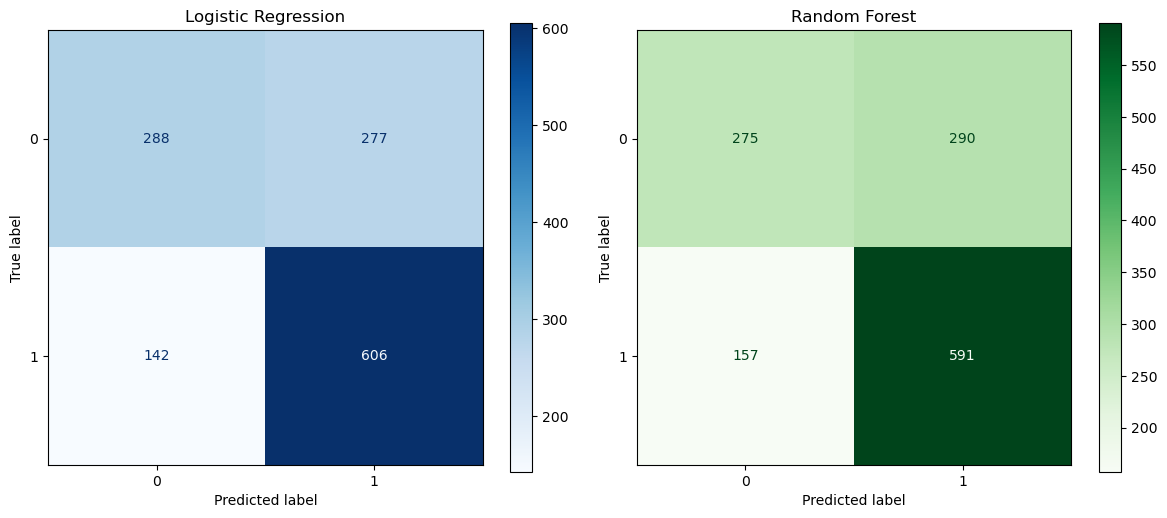

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test, ax=axes[0], cmap='Blues')
axes[0].set_title("Logistic Regression")

# Random Forest
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, ax=axes[1], cmap='Greens')
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()


                    Predicted Red	        Predicted Blue
    Actual Red      True Positives  (TP)    False Negatives (FN)
    Actual Blue     False Positives (FP)	True Negatives (TN)

## 6.2 Results: Feature Importance for Logistics Regression

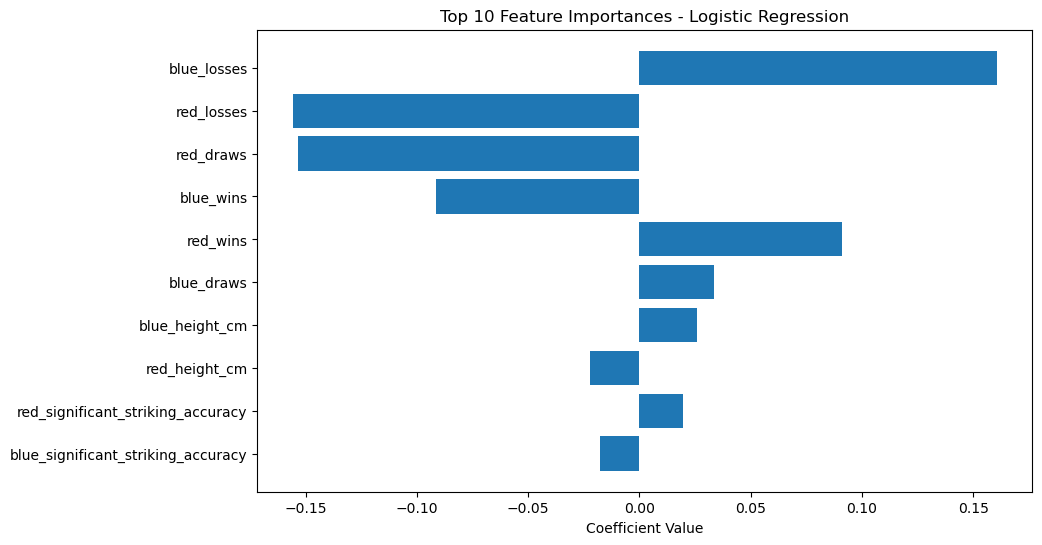

In [9]:
import pandas as pd
import numpy as np

lr_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lr.coef_[0]
}).sort_values(by='Importance', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(lr_importance['Feature'][:10], lr_importance['Importance'][:10])
plt.title("Top 10 Feature Importances - Logistic Regression")
plt.xlabel("Coefficient Value")
plt.gca().invert_yaxis()
plt.show()


### Logistic Regression: Coefficients
Each bar is a feature (stat/column).

The value of the coefficient tells you:

Positive: Increases chance of predicting "Red" (or whatever class is encoded as 1)

Negative: Increases chance of predicting "Blue" (encoded as 0)

So, big positive value → “This feature pushes toward Red winning”

big negative value → “This feature pushes toward Blue winning”

## 6.3 Results: Feature Importance for Random Forest

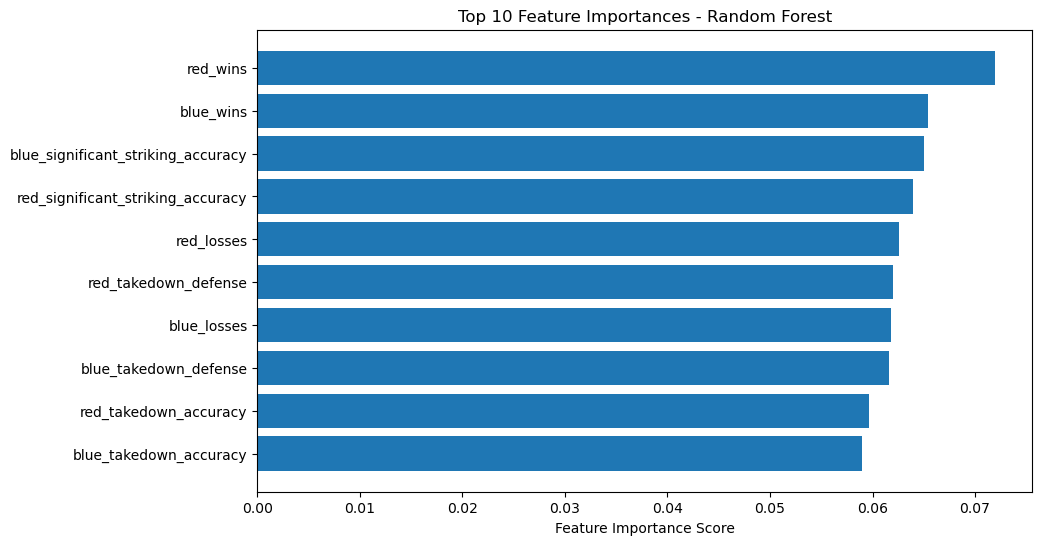

In [10]:
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(rf_importance['Feature'][:10], rf_importance['Importance'][:10])
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Feature Importance Score")
plt.gca().invert_yaxis()
plt.show()


### Random Forest: Feature Importances
All values are positive, showing how important each feature is to the decisions.

Bigger bar = that feature splits the data more effectively across the decision trees.

It doesn’t show direction (Red or Blue), just how useful the feature is.

## 6.4 Results: Side by Side View of Feature Importance of LR and RF

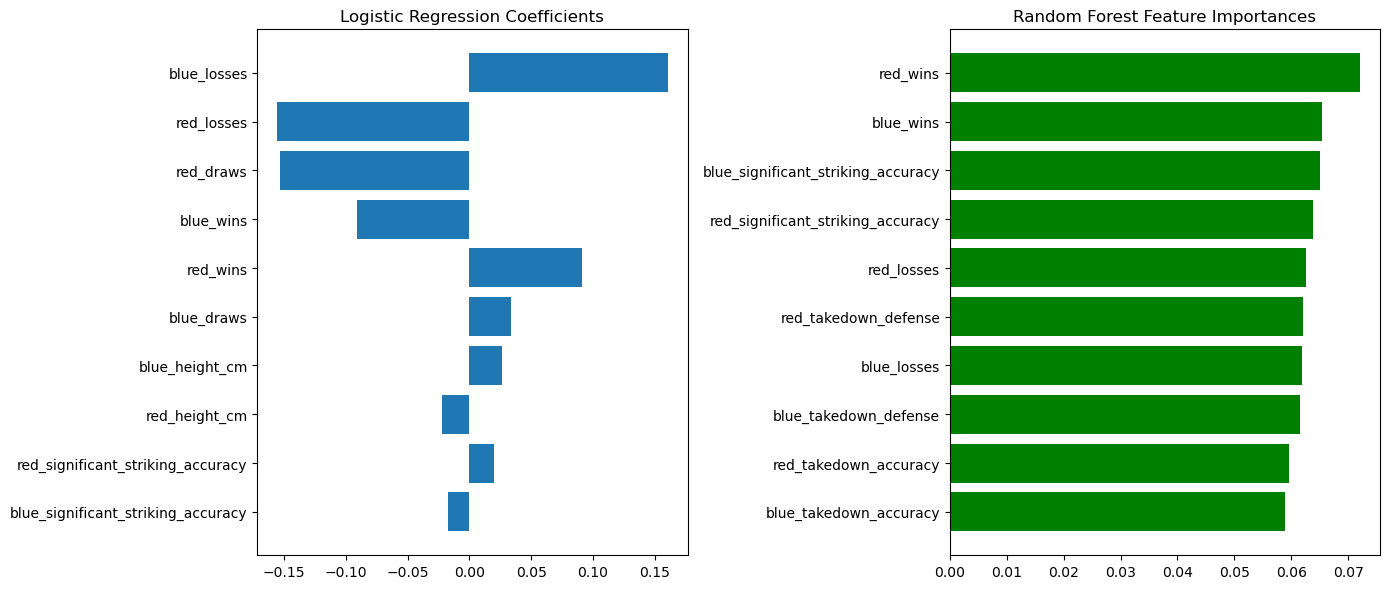

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Logistic Regression
axes[0].barh(lr_importance['Feature'][:10], lr_importance['Importance'][:10])
axes[0].set_title("Logistic Regression Coefficients")
axes[0].invert_yaxis()

# Random Forest
axes[1].barh(rf_importance['Feature'][:10], rf_importance['Importance'][:10], color='green')
axes[1].set_title("Random Forest Feature Importances")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


# 7. Predicting a Fight Outcome
### UFC 314: Alexander Volkanovski vs Diego Lopes

We will be using real stats of real fighters and see if our model predicts the results correctly!

In [12]:
import pandas as pd

sample_fight = pd.DataFrame([{
    #Alexander Volkanovski
    'red_wins': 27,
    'red_losses': 4,
    'red_draws': 0,
    'red_height_cm': 167,
    'red_weight_in_kg': 65,
    'red_reach_in_cm': 180,
    'red_significant_striking_accuracy': 56.0,
    'red_significant_strike_defence': 58.0,
    'red_takedown_accuracy': 34.0,
    'red_takedown_defense': 70.0,
    
    #Diego Lopes
    'blue_wins': 26,
    'blue_losses': 7,
    'blue_draws': 0,
    'blue_height_cm': 180,
    'blue_weight_in_kg': 65,
    'blue_reach_in_cm': 183,
    'blue_significant_striking_accuracy': 47.0,
    'blue_significant_strike_defence': 46.0,
    'blue_takedown_accuracy': 40.0,
    'blue_takedown_defense': 67.0
}])

lr_prediction = lr.predict(sample_fight)
rf_prediction = rf.predict(sample_fight)

print("Logistic Regression Prediction (1 = Red wins, 0 = Blue wins):", lr_prediction[0])
print("Random Forest Prediction (1 = Red wins, 0 = Blue wins):", rf_prediction[0])


Logistic Regression Prediction (1 = Red wins, 0 = Blue wins): 1
Random Forest Prediction (1 = Red wins, 0 = Blue wins): 1


Our model has predicted the outcome correctly of the fight which occurred over the weekend!

# 7.1 Fight Outcome Probability for UFC 314 using Random Forest

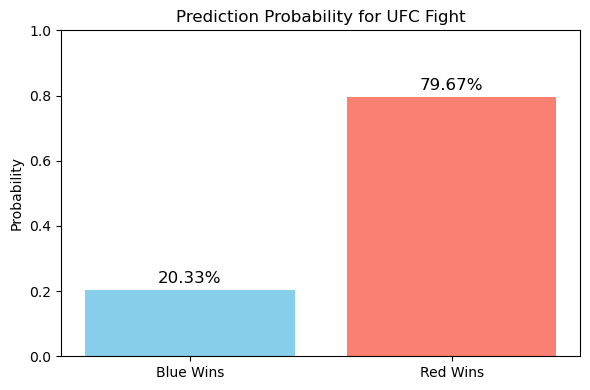

In [13]:
import matplotlib.pyplot as plt

# Get prediction probabilities
proba = rf.predict_proba(sample_fight)[0]  # [0] to extract the first row since it's only one sample

# Plot it
labels = ['Blue Wins', 'Red Wins']
colors = ['skyblue', 'salmon']

plt.figure(figsize=(6, 4))
plt.bar(labels, proba, color=colors)
plt.title('Prediction Probability for UFC Fight')
plt.ylabel('Probability')
plt.ylim(0, 1)

# Show percentage on top of bars
for i, p in enumerate(proba):
    plt.text(i, p + 0.02, f'{p:.2%}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()


# 7.2 Fight Outcome Probability for UFC 314 using Logistic Regression

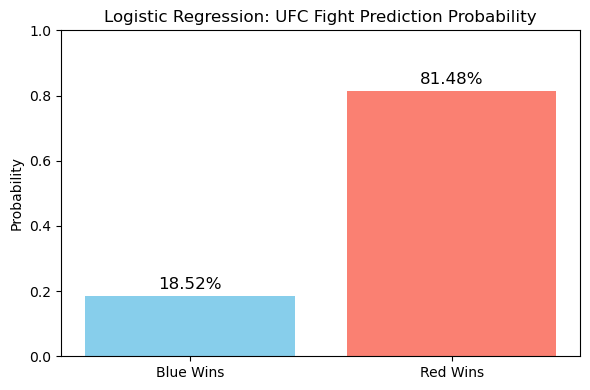

In [14]:
import matplotlib.pyplot as plt

# Get prediction probabilities
proba_lr = lr.predict_proba(sample_fight)[0]  # Assuming sample_fight is your one-row DataFrame

# Plot it
labels = ['Blue Wins', 'Red Wins']
colors = ['skyblue', 'salmon']

plt.figure(figsize=(6, 4))
plt.bar(labels, proba_lr, color=colors)
plt.title('Logistic Regression: UFC Fight Prediction Probability')
plt.ylabel('Probability')
plt.ylim(0, 1)

# Show percentage on top of bars
for i, p in enumerate(proba_lr):
    plt.text(i, p + 0.02, f'{p:.2%}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()


# 8. Predicting an "Unpredictable" Fight
### UFC 304 Belal Muhammad vs Leon Edwards
This fight is very interesting since the underdog, Belal Muhammad, beat Leon Edwards by unanimous decision, taking the welterweight title from Edwards. Let's see if our model can predict this fight based off stats.

In [15]:
import pandas as pd

sample_fight = pd.DataFrame([{
    #Leon Edwards
    'red_wins': 22,
    'red_losses': 4,
    'red_draws': 0,
    'red_height_cm': 188,
    'red_weight_in_kg': 77,
    'red_reach_in_cm': 188,
    'red_significant_striking_accuracy': 54.0,
    'red_significant_strike_defence': 53.0,
    'red_takedown_accuracy': 36.0,
    'red_takedown_defense': 63.0,
    
    #Belal Muhammad
    'blue_wins': 24,
    'blue_losses': 3,
    'blue_draws': 0,
    'blue_height_cm': 180,
    'blue_weight_in_kg': 77,
    'blue_reach_in_cm': 183,
    'blue_significant_striking_accuracy': 43.0,
    'blue_significant_strike_defence': 57.0,
    'blue_takedown_accuracy': 39.0,
    'blue_takedown_defense': 89.0
}])

lr_prediction = lr.predict(sample_fight)
rf_prediction = rf.predict(sample_fight)

print("Logistic Regression Prediction (1 = Red wins, 0 = Blue wins):", lr_prediction[0])
print("Random Forest Prediction (1 = Red wins, 0 = Blue wins):", rf_prediction[0])

Logistic Regression Prediction (1 = Red wins, 0 = Blue wins): 0
Random Forest Prediction (1 = Red wins, 0 = Blue wins): 0


Our model worked with this fight as well!

# 8.1 Fight Outcome Probability for UFC 304 using Random Forest

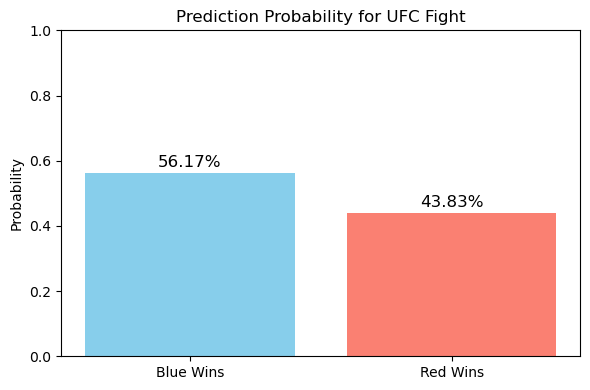

In [16]:

import matplotlib.pyplot as plt

# Get prediction probabilities
proba = rf.predict_proba(sample_fight)[0]  # [0] to extract the first row since it's only one sample

# Plot it
labels = ['Blue Wins', 'Red Wins']
colors = ['skyblue', 'salmon']

plt.figure(figsize=(6, 4))
plt.bar(labels, proba, color=colors)
plt.title('Prediction Probability for UFC Fight')
plt.ylabel('Probability')
plt.ylim(0, 1)

# Show percentage on top of bars
for i, p in enumerate(proba):
    plt.text(i, p + 0.02, f'{p:.2%}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()


# 8.2 Fight Outcome Probability for UFC 304 using Logistic Regression

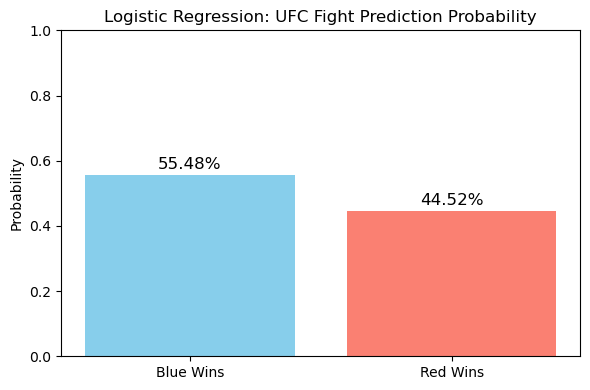

In [17]:
import matplotlib.pyplot as plt

# Get prediction probabilities
proba_lr = lr.predict_proba(sample_fight)[0]  # Assuming sample_fight is your one-row DataFrame

# Plot it
labels = ['Blue Wins', 'Red Wins']
colors = ['skyblue', 'salmon']

plt.figure(figsize=(6, 4))
plt.bar(labels, proba_lr, color=colors)
plt.title('Logistic Regression: UFC Fight Prediction Probability')
plt.ylabel('Probability')
plt.ylim(0, 1)

# Show percentage on top of bars
for i, p in enumerate(proba_lr):
    plt.text(i, p + 0.02, f'{p:.2%}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()


We can see here, this fight is a lot closer than our previous prediction. However, the model still predicts that Belal would win this matchup. (Which is correct)

# 9. Predicting a Future Fight
### UFC 315: Belal vs Jack
As of current, we are going to predict a fight that will happen in the future and see if our model can be used for gambling.

In [20]:
import pandas as pd

sample_fight = pd.DataFrame([{
    #Belal Muhammad
    'red_wins': 25,
    'red_losses': 3,
    'red_draws': 0,
    'red_height_cm': 180,
    'red_weight_in_kg': 77,
    'red_reach_in_cm': 183,
    'red_significant_striking_accuracy': 43.0,
    'red_significant_strike_defence': 57.0,
    'red_takedown_accuracy': 39.0,
    'red_takedown_defense': 89.0,
    
    #Jack Maddalena
    'blue_wins': 17,
    'blue_losses': 2,
    'blue_draws': 0,
    'blue_height_cm': 180,
    'blue_weight_in_kg': 77,
    'blue_reach_in_cm': 185,
    'blue_significant_striking_accuracy': 53.0,
    'blue_significant_strike_defence': 66.0,
    'blue_takedown_accuracy': 16.0,
    'blue_takedown_defense': 70.0
}])

lr_prediction = lr.predict(sample_fight)
rf_prediction = rf.predict(sample_fight)

print("Logistic Regression Prediction (1 = Red wins, 0 = Blue wins):", lr_prediction[0])
print("Random Forest Prediction (1 = Red wins, 0 = Blue wins):", rf_prediction[0])

Logistic Regression Prediction (1 = Red wins, 0 = Blue wins): 1
Random Forest Prediction (1 = Red wins, 0 = Blue wins): 1


# 9.1 Probability of UFC 315 Outcome

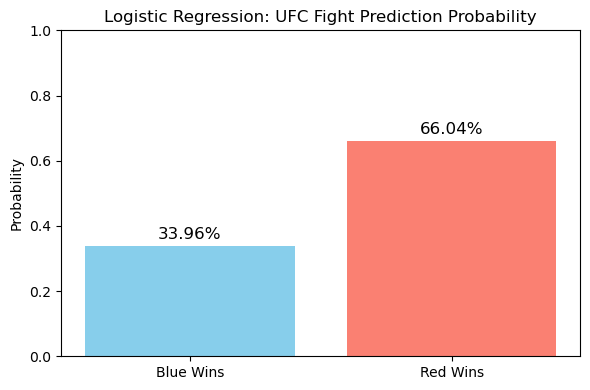

In [21]:
import matplotlib.pyplot as plt

# Get prediction probabilities
proba_lr = lr.predict_proba(sample_fight)[0]  # Assuming sample_fight is your one-row DataFrame

# Plot it
labels = ['Blue Wins', 'Red Wins']
colors = ['skyblue', 'salmon']

plt.figure(figsize=(6, 4))
plt.bar(labels, proba_lr, color=colors)
plt.title('Logistic Regression: UFC Fight Prediction Probability')
plt.ylabel('Probability')
plt.ylim(0, 1)

# Show percentage on top of bars
for i, p in enumerate(proba_lr):
    plt.text(i, p + 0.02, f'{p:.2%}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()